In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import statsmodels.api as sm

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from stargazer.stargazer import Stargazer 
from sklearn.linear_model import LogisticRegressionCV

from statsmodels.discrete.discrete_model import Logit

In [2]:
dat = gpd.read_file('modified_data/reviews_demog_2020.gpkg')
dat_2010 = gpd.read_file('modified_data/reviews_demog_2010.gpkg')

# for plotting
neighborhoods = gpd.read_file('modified_data/renamed_neighborhoods.gpkg')

In [93]:
dat.crs

<Projected CRS: EPSG:2272>
Name: NAD83 / Pennsylvania South (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Pennsylvania - counties of Adams; Allegheny; Armstrong; Beaver; Bedford; Berks; Blair; Bucks; Butler; Cambria; Chester; Cumberland; Dauphin; Delaware; Fayette; Franklin; Fulton; Greene; Huntingdon; Indiana; Juniata; Lancaster; Lawrence; Lebanon; Lehigh; Mifflin; Montgomery; Northampton; Perry; Philadelphia; Schuylkill; Snyder; Somerset; Washington; Westmoreland; York.
- bounds: (-80.53, 39.71, -74.72, 41.18)
Coordinate Operation:
- name: SPCS83 Pennsylvania South zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [3]:
dat['text'] = dat.text.str.lower()
dat = dat.dropna(subset=['text', 'gentrified']).reset_index(drop=True)

In [ ]:
dat.categories

0         Restaurants, Food, Bubble Tea, Coffee & Tea, B...
1         Restaurants, Food, Bubble Tea, Coffee & Tea, B...
2         Restaurants, Food, Bubble Tea, Coffee & Tea, B...
3         Restaurants, Food, Bubble Tea, Coffee & Tea, B...
4         Restaurants, Food, Bubble Tea, Coffee & Tea, B...
                                ...                        
681784                                 Restaurants, Mexican
681785                                 Restaurants, Mexican
681786                                 Restaurants, Mexican
681787                                 Restaurants, Mexican
681788                                 Restaurants, Mexican
Name: categories, Length: 681789, dtype: object

In [91]:
mask = dat['categories'].str.contains(r'brew|beer', case=False, na=False)
filtered = dat[mask]
filtered.categories

655       Eatertainment, Arts & Entertainment, Brewpubs,...
656       Eatertainment, Arts & Entertainment, Brewpubs,...
657       Eatertainment, Arts & Entertainment, Brewpubs,...
658       Eatertainment, Arts & Entertainment, Brewpubs,...
659       Eatertainment, Arts & Entertainment, Brewpubs,...
                                ...                        
679432    Gastropubs, Food, Brewpubs, Breweries, Restaur...
679433    Gastropubs, Food, Brewpubs, Breweries, Restaur...
679434    Gastropubs, Food, Brewpubs, Breweries, Restaur...
679435    Gastropubs, Food, Brewpubs, Breweries, Restaur...
679436    Gastropubs, Food, Brewpubs, Breweries, Restaur...
Name: categories, Length: 61632, dtype: object

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import re

# 1. Setup (assuming 'undf' is a DataFrame)
# corpus_undf <- corpus(undf, text_field = "text")
texts = dat['text']

# 2. Preprocessing Function (tokens, remove_punct, remove_numbers, wordstem)
stemmer = SnowballStemmer("english")
stop_words = set(stopwords.words('english'))

def preprocess(text):
    # remove_punct and remove_numbers using regex
    #text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # tokens_wordstem and stopwords remove
    tokens = [stemmer.stem(word) for word in text.split() if word not in stop_words]
    return " ".join(tokens)

# Apply preprocessing
processed_texts = texts.apply(preprocess)

# 3. Create DFM (Document-Feature Matrix)
# dfm <- dfm(toks)
vectorizer = CountVectorizer()
dfm = vectorizer.fit_transform(processed_texts)

# 4. Trim DFM (min_docfreq = 0.05)
# dfm_trim(dfm, min_docfreq = 0.05, docfreq_type = "prop")
trimmed_vectorizer = CountVectorizer(min_df=0.05)
dfm_trimmed = trimmed_vectorizer.fit_transform(processed_texts)

# Convert to DataFrame for viewing (optional)
dfm_trimmed_df = pd.DataFrame(
    dfm_trimmed.toarray(), 
    columns=trimmed_vectorizer.get_feature_names_out()
)

print(dfm_trimmed_df)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ellabartt/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


        actual  also  alway  amaz  anoth  appet  area  around  ask  atmospher  \
0            0     0      0     0      0      0     1       0    0          0   
1            0     0      1     0      0      0     0       0    0          0   
2            0     1      1     0      0      0     0       0    0          0   
3            0     1      0     0      0      0     0       0    0          0   
4            0     0      0     0      0      0     0       0    0          0   
...        ...   ...    ...   ...    ...    ...   ...     ...  ...        ...   
677127       0     1      0     0      0      0     0       0    0          0   
677128       0     1      0     2      0      0     0       0    0          0   
677129       0     1      0     1      0      0     0       0    0          0   
677130       0     1      0     0      0      0     0       0    0          0   
677131       0     1      0     0      2      0     0       0    0          0   

        ...  wasnt  way  we

In [4]:
dat['id'] = dat.index

In [6]:
from sklearn.model_selection import train_test_split
training, validation = train_test_split(
    dat, 
    train_size=0.75, 
    random_state=32123
)


In [7]:
#Create separate subsets for DFM
dfmat_train = dfm_trimmed_df.loc[training.index]
dfmat_val = dfm_trimmed_df.loc[validation.index]
X_train = dfmat_train
X_test = dfmat_val
y_train = dat.loc[training.index].gentrified
y_test = dat.loc[validation.index].gentrified

In [8]:
dfmat_train

,actual,also,alway,amaz,anoth,appet,area,around,ask,atmospher,...,wasnt,way,week,well,went,work,worth,would,year,your
519793,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,1,0,1,0
133753,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
506968,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
438218,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
491453,0,0,0,1,0,0,0,1,2,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
529997,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,2,0,0
262968,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
241115,2,0,0,0,0,1,0,1,0,0,...,0,2,0,2,0,0,0,1,0,0
218058,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [9]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import confusion_matrix, classification_report

lasso_model = LogisticRegression(penalty='l1', solver = 'saga', random_state=4323, )
lasso_model.fit(X_train, y_train)

testing = []
for i, j in enumerate(X_train.columns):
    testing.append({
        'word': j,
        'rank': lasso_model.coef_[0][i],
        'rank_abs': np.abs(lasso_model.coef_[0][i])
    })
importance = pd.DataFrame(testing)
importance = importance.sort_values(by = 'rank', ascending = False)

# --- 4. Out of Sample Predictions ---
# Probability predictions (type="response")
pred_probs = lasso_model.predict_proba(X_test)[:, 1]

# Confusion Matrix (Table)
# Since R's index 40 or 1 refers to specific lambdas, in Python you'd just 
# predict using the fitted model or specific thresholds.
print(confusion_matrix(y_test, lasso_model.predict(X_test)))

confusion_matrix(y_test, lasso_model.predict(X_test))

[[153205     51]
 [ 16011     16]]


array([[153205,     51],
       [ 16011,     16]])

In [10]:
importance.sort_values(by = 'rank_abs', ascending = False).head(10)

,word,rank,rank_abs
16,beer,0.219276,0.219276
6,area,0.214978,0.214978
29,citi,-0.202774,0.202774
100,meat,0.185773,0.185773
39,dessert,-0.178179,0.178179
121,pizza,0.177316,0.177316
155,soup,-0.175340,0.175340
120,philli,-0.159360,0.159360
89,live,0.142340,0.142340
146,select,0.132319,0.132319


In [11]:
print(classification_report(y_test, lasso_model.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95    153256
         1.0       0.24      0.00      0.00     16027

    accuracy                           0.91    169283
   macro avg       0.57      0.50      0.48    169283
weighted avg       0.84      0.91      0.86    169283



In [12]:
# --- 5. Cross-Validation (cv.glmnet) ---
# Cs is the number of inverse-lambdas to try
cv_model = LogisticRegressionCV(
    penalty='l1', 
    solver='saga', 
    cv=5, 
    scoring='accuracy', 
    class_weight='balanced' # Replaces manual weights
)
cv_model.fit(X_train, y_train)

testing2 = []
for i, j in enumerate(X_train.columns):
    testing2.append({
        'word': j,
        'rank': cv_model.coef_[0][i],
        'rank_abs': np.abs(cv_model.coef_[0][i])
    })
importance2 = pd.DataFrame(testing2)
importance2 = importance2.sort_values(by = 'rank', ascending = False)

pred_val = cv_model.predict(X_test)
tab_val = confusion_matrix(y_test, pred_val)
print("Final Validation Table:\n", tab_val)
importance2.head()

Final Validation Table:
 [[132859  20397]
 [ 12303   3724]]


,word,rank,rank_abs
121,pizza,0.068289,0.068289
16,beer,0.061913,0.061913
0,actual,0.000000,0.000000
125,portion,0.000000,0.000000
127,price,0.000000,0.000000


In [13]:
print(classification_report(y_test, cv_model.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.92      0.87      0.89    153256
         1.0       0.15      0.23      0.19     16027

    accuracy                           0.81    169283
   macro avg       0.53      0.55      0.54    169283
weighted avg       0.84      0.81      0.82    169283



In [14]:
importance2.tail()

,word,rank,rank_abs
69,get,0.0,0.0
70,give,0.0,0.0
71,go,0.0,0.0
72,good,0.0,0.0
197,your,0.0,0.0


In [5]:
import statsmodels.formula.api as smf

dat['authenticity'] = np.where(dat['text'].str.contains('authent'), 1, 0)
dat['beer'] = np.where(dat['text'].str.contains('beer'), 1, 0)
dat['simple'] = np.where(dat['text'].str.contains('simpl'), 1, 0)
dat['gentrified'] = dat['gentrified'].astype(int)
dat.columns


Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'neighborhood', 'gentrified',
       'review_id', 'user_id', 'useful', 'funny', 'cool', 'text', 'date',
       'TRACTCE', 'geographic_area_name', 'tot_pop', 'prop_black',
       'prop_asian', 'prop_hispanic_or_latino', 'prop_white_only',
       'overlap_area', 'prop_white_wavg', 'predom_poc', 'no_predom_race',
       'geometry', 'id', 'authenticity', 'beer', 'simple'],
      dtype='object')

In [45]:
authenticity_model = smf.logit('gentrified ~ authenticity', data=dat).fit()
print(authenticity_model.summary())

Optimization terminated successfully.
         Current function value: 0.311943
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             gentrified   No. Observations:               681789
Model:                          Logit   Df Residuals:                   681787
Method:                           MLE   Df Model:                            1
Date:                Sat, 09 May 2026   Pseudo R-squ.:               0.0001632
Time:                        11:31:05   Log-Likelihood:            -2.1268e+05
converged:                       True   LL-Null:                   -2.1271e+05
Covariance Type:            nonrobust   LLR p-value:                 7.873e-17
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -2.2586      0.004   -538.357      0.000      -2.267      -2.250
authenticity    -0.2254

In [46]:
marginal_effects = authenticity_model.get_margeff()
print(marginal_effects.summary())

        Logit Marginal Effects       
Dep. Variable:             gentrified
Method:                          dydx
At:                           overall
                  dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
authenticity    -0.0192      0.002     -8.082      0.000      -0.024      -0.015


In [43]:
np.exp(-0.171)

np.float64(0.8428215734716199)

In [20]:
dat.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'neighborhood', 'gentrified',
       'review_id', 'user_id', 'useful', 'funny', 'cool', 'text', 'date',
       'TRACTCE', 'geographic_area_name', 'tot_pop', 'prop_black',
       'prop_asian', 'prop_hispanic_or_latino', 'prop_white_only',
       'overlap_area', 'prop_white_wavg', 'predom_poc', 'no_predom_race',
       'geometry', 'authenticity', 'beer', 'simple', 'dev_resids'],
      dtype='object')

In [7]:
# collect residauls from model 1 for evaluation and plotting

# Source: https://library.virginia.edu/data/articles/understanding-deviance-residuals
# Deviance residuals measure how much probabilities estimated from our model differ from the observed proportions of successes
dat['dev_resids_mod1'] = authenticity_model.resid_dev
restaurant_agg = dat.groupby('business_id').agg(
    name = ('name', 'first'),
    avg_mod1_resids = ('dev_resids_mod1', 'mean'),
    gentrified = ('gentrified', 'first'),
    geometry = ('geometry', 'first')
)


restaurant_agg.head()

,name,avg_mod1_resids,gentrified,geometry
business_id,,,,
-0M0b-XhtFagyLmsBtOe8w,Paris Wine Bar,2.176791,1,POINT (2690029.607 241514.098)
-0PN_KFPtbnLQZEeb23XiA,Mr Wong's Chinese Restaurant,-0.445848,0,POINT (2689764.892 225328.864)
-0TffRSXXIlBYVbb5AwfTg,IndeBlue Modern Indian Food & Spirits,-0.443755,0,POINT (2694009.389 234731.378)
-0eUa8TsXFFy0FCxHYmrjg,Waterfront Gourmet Cafe & Deli,-0.445848,0,POINT (2686862.838 235958.162)
-1B9pP_CrRBJYPICE5WbRA,Spice 28,-0.443974,0,POINT (2694097.855 235406.06)


In [66]:
# we underpredict actual gentrified areas
print(np.mean(restaurant_agg[restaurant_agg['gentrified']==1].avg_mod1_resids))

# we overpredict non-gentrified areas
print(np.mean(restaurant_agg[restaurant_agg['gentrified']==0].avg_mod1_resids))

2.1733820118116034
-0.44473053463570555


In [28]:
neighborhoods.columns
neighborhoods = neighborhoods.to_crs(dat.crs)

neighborhoods.crs

<Projected CRS: EPSG:2272>
Name: NAD83 / Pennsylvania South (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Pennsylvania - counties of Adams; Allegheny; Armstrong; Beaver; Bedford; Berks; Blair; Bucks; Butler; Cambria; Chester; Cumberland; Dauphin; Delaware; Fayette; Franklin; Fulton; Greene; Huntingdon; Indiana; Juniata; Lancaster; Lawrence; Lebanon; Lehigh; Mifflin; Montgomery; Northampton; Perry; Philadelphia; Schuylkill; Snyder; Somerset; Washington; Westmoreland; York.
- bounds: (-80.53, 39.71, -74.72, 41.18)
Coordinate Operation:
- name: SPCS83 Pennsylvania South zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

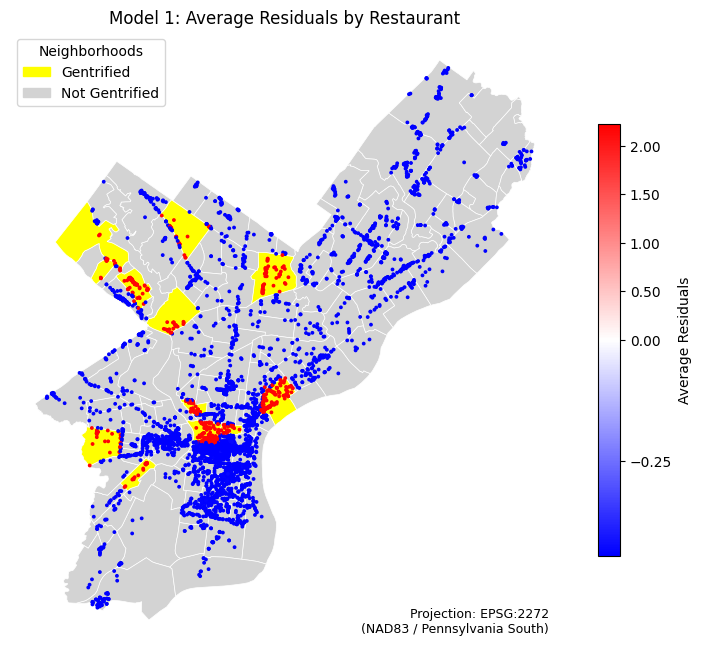

In [ ]:
restaurant_agg = gpd.GeoDataFrame(restaurant_agg)

fig, ax = plt.subplots(1, 1, figsize=(10,8))
min_resid = restaurant_agg['avg_mod1_resids'].min()
max_resid = restaurant_agg['avg_mod1_resids'].max()

# get data range and center white as zero
color_norm = mcolors.TwoSlopeNorm(vmin = min_resid, vcenter=0, vmax=max_resid)

# plot non-gentrified areas as a light grey
neighborhoods[neighborhoods['gentrified'] ==0].plot(
    ax=ax,
    color='lightgrey',
    edgecolor='white',
    linewidth=0.5
)

# plot gentrified areas in yellow
neighborhoods[neighborhoods['gentrified'] ==1].plot(
    ax=ax,
    color='yellow',
    edgecolor='white',
    linewidth=0.5
)

restaurant_agg.plot(column="avg_mod1_resids", 
                    cmap = "bwr",
                    markersize=3,
                    norm=color_norm,
                    legend=True,
                    legend_kwds={"ticks": [-0.5, -0.25, 0, 0.5, 1.0, 1.5, 2.0],
                                 "label": "Average Residuals",
                                 "shrink": 0.7},
                    ax=ax)

# legend for the gentrified areas
patches = [mpatches.Patch(color='yellow', label='Gentrified'),
           mpatches.Patch(color='lightgrey', label='Not Gentrified')]
ax.legend(handles=patches, title="Neighborhoods")



textstr = "Projection: EPSG:2272\n(NAD83 / Pennsylvania South)"
#props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax.text(
    0.98, 0.02,         
    textstr,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='bottom',
    horizontalalignment='right',
    #bbox=props
)

plt.title("Model 1: Average Residuals by Restaurant")
ax.set_axis_off()
plt.show()

In [103]:
dat_temp = dat.copy()
dat_temp['predom_poc'] = np.where(dat_temp['prop_white_wavg'] < 0.5, 1, 0)

In [104]:
auth_poc = smf.logit('predom_poc ~ authenticity', data=dat_temp).fit()
auth_poc.summary()

Optimization terminated successfully.
         Current function value: 0.551793
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             predom_poc   No. Observations:               681789
Model:                          Logit   Df Residuals:                   681787
Method:                           MLE   Df Model:                            1
Date:                Sun, 10 May 2026   Pseudo R-squ.:               0.0002992
Time:                        22:41:09   Log-Likelihood:            -3.7621e+05
converged:                       True   LL-Null:                   -3.7632e+05
Covariance Type:            nonrobust   LLR p-value:                 6.730e-51
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.1558      0.003   -401.676      0.000      -1.161      -1.150
authenticity     0.2516      0.016     15.271      0.000       0.219       0.284
================================================================================
"""

In [105]:
auth_poc.get_margeff(at="mean").summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:             predom_poc
Method:                          dydx
At:                              mean
================================================================================
                  dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
authenticity     0.0460      0.003     15.274      0.000       0.040       0.052
================================================================================
"""

In [101]:
authenticity_int_model = smf.logit('gentrified ~ authenticity + predom_poc + no_predom_race + authenticity:predom_poc', data=dat).fit()
print(authenticity_int_model.summary())

Optimization terminated successfully.
         Current function value: 0.305430
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             gentrified   No. Observations:               681789
Model:                          Logit   Df Residuals:                   681784
Method:                           MLE   Df Model:                            4
Date:                Sun, 10 May 2026   Pseudo R-squ.:                 0.02104
Time:                        22:35:16   Log-Likelihood:            -2.0824e+05
converged:                       True   LL-Null:                   -2.1271e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -2.0526      0.005   -452.561      0.000      -2.062   

In [102]:
authenticity_int_model.get_margeff(at="mean").summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:             gentrified
Method:                          dydx
At:                              mean
===========================================================================================
                             dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
authenticity               -0.0216      0.002     -8.784      0.000      -0.026      -0.017
predom_poc                 -0.0732      0.001    -56.512      0.000      -0.076      -0.071
no_predom_race             -0.0910      0.001    -71.106      0.000      -0.093      -0.088
authenticity:predom_poc     0.0551      0.006      9.201      0.000       0.043       0.067
===========================================================================================
"""

In [40]:
np.exp(-2.267)

np.float64(0.10362258199341358)

In [ ]:
# collect residuals from model 4 for evaluation and mapping 
dat['dev_resids_mod2'] = authenticity_int_model.resid_dev
restaurant_agg = dat.groupby('business_id').agg(
    name = ('name', 'first'),
    avg_mod2_resids = ('dev_resids_mod2', 'mean'),
    gentrified = ('gentrified', 'first'),
    geometry = ('geometry', 'first')
)


restaurant_agg.head()

,name,avg_mod2_resids,gentrified,geometry
business_id,,,,
-0M0b-XhtFagyLmsBtOe8w,Paris Wine Bar,2.146769,1,POINT (2690029.607 241514.098)
-0PN_KFPtbnLQZEeb23XiA,Mr Wong's Chinese Restaurant,-0.462058,0,POINT (2689764.892 225328.864)
-0TffRSXXIlBYVbb5AwfTg,IndeBlue Modern Indian Food & Spirits,-0.459344,0,POINT (2694009.389 234731.378)
-0eUa8TsXFFy0FCxHYmrjg,Waterfront Gourmet Cafe & Deli,-0.462058,0,POINT (2686862.838 235958.162)
-1B9pP_CrRBJYPICE5WbRA,Spice 28,-0.459628,0,POINT (2694097.855 235406.06)


In [99]:
len(dat.neighborhood.unique())

148

In [100]:
min(dat.date)

'2005-02-16 04:06:26'

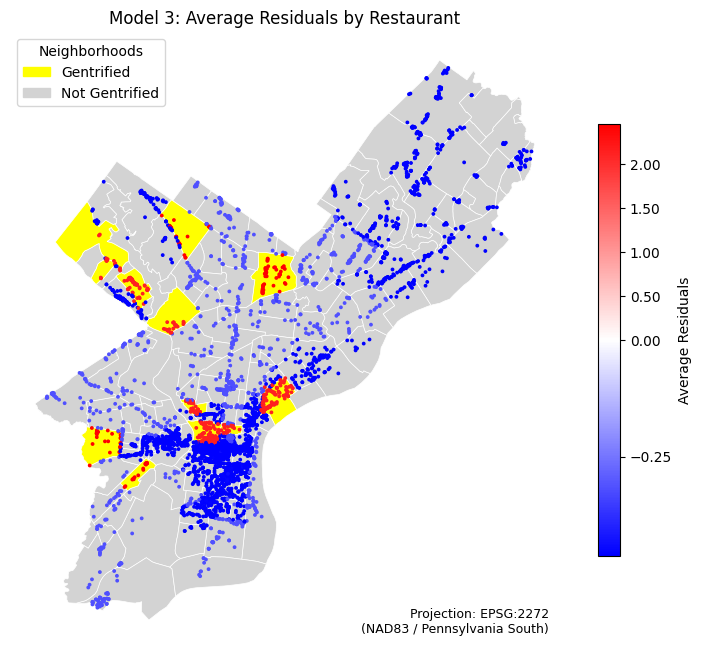

In [94]:
restaurant_agg = gpd.GeoDataFrame(restaurant_agg)

fig, ax = plt.subplots(1, 1, figsize=(10,8))
min_resid = restaurant_agg['avg_mod2_resids'].min()
max_resid = restaurant_agg['avg_mod2_resids'].max()

# get data range and center white as zero
color_norm = mcolors.TwoSlopeNorm(vmin = min_resid, vcenter=0, vmax=max_resid)

# plot non-gentrified areas as a light grey
neighborhoods[neighborhoods['gentrified'] ==0].plot(
    ax=ax,
    color='lightgrey',
    edgecolor='white',
    linewidth=0.5
)

# plot gentrified areas in yellow
neighborhoods[neighborhoods['gentrified'] ==1].plot(
    ax=ax,
    color='yellow',
    edgecolor='white',
    linewidth=0.5
)

restaurant_agg.plot(column="avg_mod2_resids", 
                    cmap = "bwr",
                    markersize=3,
                    norm=color_norm,
                    legend=True,
                    legend_kwds={"ticks": [-0.5, -0.25, 0, 0.5, 1.0, 1.5, 2.0],
                                 "label": "Average Residuals",
                                 "shrink": 0.7},

                    ax=ax)

# legend for the gentrified areas
patches = [mpatches.Patch(color='yellow', label='Gentrified'),
           mpatches.Patch(color='lightgrey', label='Not Gentrified')]
ax.legend(handles=patches, title="Neighborhoods")

textstr = "Projection: EPSG:2272\n(NAD83 / Pennsylvania South)"
#props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax.text(
    0.98, 0.02,         
    textstr,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='bottom',
    horizontalalignment='right',
    #bbox=props
)

plt.title("Model 3: Average Residuals by Restaurant")
ax.set_axis_off()
plt.show()

In [64]:
main_effects_model = smf.logit('gentrified ~ authenticity + predom_poc', data=dat).fit()
print(main_effects_model.summary())

Optimization terminated successfully.
         Current function value: 0.309990
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             gentrified   No. Observations:               681789
Model:                          Logit   Df Residuals:                   681786
Method:                           MLE   Df Model:                            2
Date:                Sat, 09 May 2026   Pseudo R-squ.:                0.006423
Time:                        15:39:35   Log-Likelihood:            -2.1135e+05
converged:                       True   LL-Null:                   -2.1271e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -2.1854      0.004   -501.840      0.000      -2.194      -2.177
authenticity    -0.1927

In [66]:
main_effects_model.get_margeff(at="mean").summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:             gentrified
Method:                          dydx
At:                              mean
================================================================================
                  dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
authenticity    -0.0161      0.002     -6.901      0.000      -0.021      -0.012
predom_poc      -0.0632      0.001    -47.911      0.000      -0.066      -0.061
================================================================================
"""

In [9]:
beer_model = smf.logit('gentrified ~ beer', data=dat).fit()
print(beer_model.summary())

Optimization terminated successfully.
         Current function value: 0.311634
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             gentrified   No. Observations:               677132
Model:                          Logit   Df Residuals:                   677130
Method:                           MLE   Df Model:                            1
Date:                Fri, 08 May 2026   Pseudo R-squ.:                0.005819
Time:                        13:20:29   Log-Likelihood:            -2.1102e+05
converged:                       True   LL-Null:                   -2.1225e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.3257      0.004   -521.618      0.000      -2.334      -2.317
beer           0.6499      0.

In [88]:
# collect residuals from beer for evaluation and mapping 
dat['dev_resids_beer'] = beer_model.resid_dev
restaurant_agg = dat.groupby('business_id').agg(
    name = ('name', 'first'),
    avg_beer_resids = ('dev_resids_beer', 'mean'),
    gentrified = ('gentrified', 'first'),
    geometry = ('geometry', 'first')
)


restaurant_agg.head()

,name,avg_beer_resids,gentrified,geometry
business_id,,,,
-0M0b-XhtFagyLmsBtOe8w,Paris Wine Bar,-0.431820,1,POINT (2690029.607 241514.098)
-0PN_KFPtbnLQZEeb23XiA,Mr Wong's Chinese Restaurant,-0.445818,0,POINT (2689764.892 225328.864)
-0TffRSXXIlBYVbb5AwfTg,IndeBlue Modern Indian Food & Spirits,-0.433725,0,POINT (2694009.389 234731.378)
-0eUa8TsXFFy0FCxHYmrjg,Waterfront Gourmet Cafe & Deli,-0.437319,0,POINT (2686862.838 235958.162)
-1B9pP_CrRBJYPICE5WbRA,Spice 28,-0.373253,0,POINT (2694097.855 235406.06)


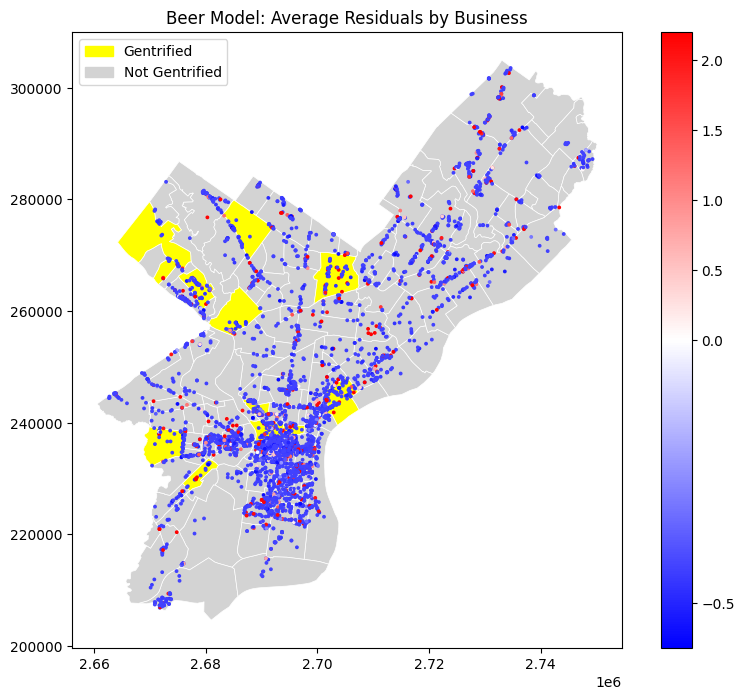

In [ ]:
restaurant_agg = gpd.GeoDataFrame(restaurant_agg)

fig, ax = plt.subplots(1, 1, figsize=(10,8))
min_resid = restaurant_agg['avg_beer_resids'].min()
max_resid = restaurant_agg['avg_beer_resids'].max()

# get data range and center white as zero
color_norm = mcolors.TwoSlopeNorm(vmin = min_resid, vcenter=0, vmax=max_resid)

# plot non-gentrified areas as a light grey
neighborhoods[neighborhoods['gentrified'] ==0].plot(
    ax=ax,
    color='lightgrey',
    edgecolor='white',
    linewidth=0.5
)

# plot gentrified areas in yellow
neighborhoods[neighborhoods['gentrified'] ==1].plot(
    ax=ax,
    color='yellow',
    edgecolor='white',
    linewidth=0.5
)

restaurant_agg.plot(column="avg_beer_resids", 
                    cmap = "bwr",
                    markersize=3,
                    norm=color_norm,
                    legend=True,
                    #legend_kwds={"ticks": [-0.5, -0.25, 0, 0.5, 1.0, 1.5, 2.0]},
                    ax=ax)

# legend for the gentrified areas
patches = [mpatches.Patch(color='yellow', label='Gentrified'),
           mpatches.Patch(color='lightgrey', label='Not Gentrified')]
ax.legend(handles=patches, title="Neighborhoods")


plt.title("Beer Model: Average Residuals by Business")
plt.show()

In [10]:
simple_model = smf.logit('gentrified ~ simple', data=dat).fit()
print(simple_model.summary())

Optimization terminated successfully.
         Current function value: 0.313445
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             gentrified   No. Observations:               677132
Model:                          Logit   Df Residuals:                   677130
Method:                           MLE   Df Model:                            1
Date:                Fri, 08 May 2026   Pseudo R-squ.:               4.004e-05
Time:                        13:20:39   Log-Likelihood:            -2.1224e+05
converged:                       True   LL-Null:                   -2.1225e+05
Covariance Type:            nonrobust   LLR p-value:                 3.740e-05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.2534      0.004   -534.181      0.000      -2.262      -2.245
simple        -0.0950      0.

## Using a regional holdout

Model 2

In [ ]:
X = dat[['authenticity', 'predom_poc']]
X['authenticity:predom_poc'] = X['authenticity']*X['predom_poc']
y = dat['gentrified']

In [70]:
X['authenticity:predom_poc'].value_counts()

authenticity:predom_poc
0    678410
1      3379
Name: count, dtype: int64

/var/folders/rz/h3gzrv2j09s6d_5vmn0bglw40000gn/T/ipykernel_4461/2117296946.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['authenticity:predom_poc'] = X['authenticity']*X['predom_poc']


northwest
              precision    recall  f1-score   support

           0       0.78      1.00      0.88    129740
           1       0.00      0.00      0.00     36323

    accuracy                           0.78    166063
   macro avg       0.39      0.50      0.44    166063
weighted avg       0.61      0.78      0.69    166063

[[129740      0]
 [ 36323      0]]


/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

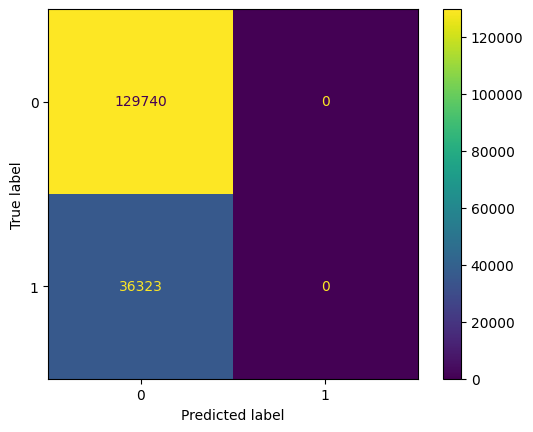

                           Logit Regression Results                           
Dep. Variable:             gentrified   No. Observations:               515726
Model:                          Logit   Df Residuals:                   515722
Method:                           MLE   Df Model:                            3
Date:                Sat, 09 May 2026   Pseudo R-squ.:                0.005406
Time:                        10:04:06   Log-Likelihood:            -1.0780e+05
converged:                       True   LL-Null:                   -1.0839e+05
Covariance Type:            nonrobust   LLR p-value:                9.790e-254
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -2.7828      0.007   -427.201      0.000      -2.796      -2.770
authenticity               -0.2684      0.045     -5.942      0.000      -0.357      -0.180


/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

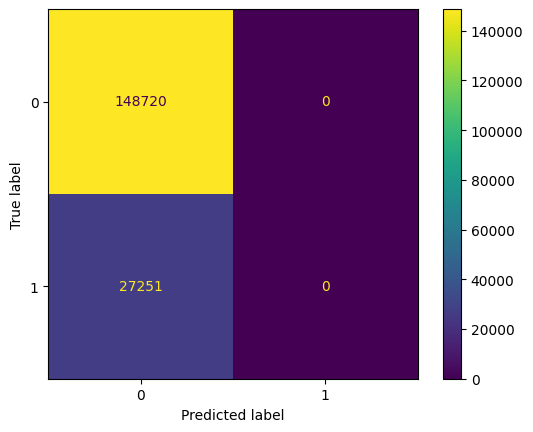

                           Logit Regression Results                           
Dep. Variable:             gentrified   No. Observations:               505818
Model:                          Logit   Df Residuals:                   505814
Method:                           MLE   Df Model:                            3
Date:                Sat, 09 May 2026   Pseudo R-squ.:               0.0007558
Time:                        10:04:07   Log-Likelihood:            -1.3209e+05
converged:                       True   LL-Null:                   -1.3219e+05
Covariance Type:            nonrobust   LLR p-value:                 4.624e-43
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -2.5460      0.006   -449.454      0.000      -2.557      -2.535
authenticity               -0.3538      0.040     -8.743      0.000      -0.433      -0.275


/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

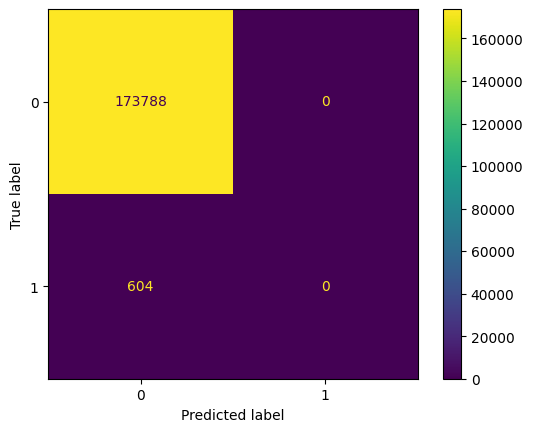

                           Logit Regression Results                           
Dep. Variable:             gentrified   No. Observations:               507397
Model:                          Logit   Df Residuals:                   507393
Method:                           MLE   Df Model:                            3
Date:                Sat, 09 May 2026   Pseudo R-squ.:                 0.01632
Time:                        10:04:08   Log-Likelihood:            -1.8834e+05
converged:                       True   LL-Null:                   -1.9146e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -1.8137      0.004   -407.225      0.000      -1.822      -1.805
authenticity               -0.3109      0.031     -9.993      0.000      -0.372      -0.250


/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


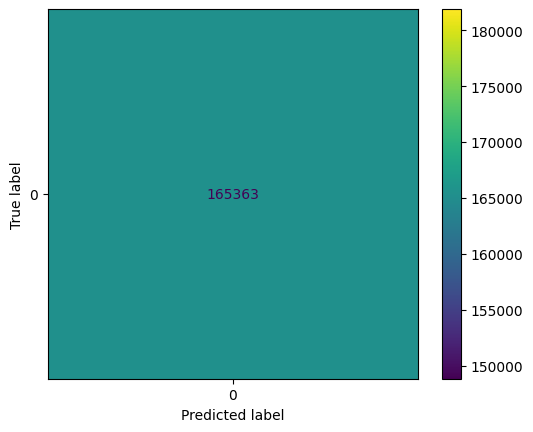

                           Logit Regression Results                           
Dep. Variable:             gentrified   No. Observations:               516426
Model:                          Logit   Df Residuals:                   516422
Method:                           MLE   Df Model:                            3
Date:                Sat, 09 May 2026   Pseudo R-squ.:                 0.01270
Time:                        10:04:08   Log-Likelihood:            -1.9138e+05
converged:                       True   LL-Null:                   -1.9384e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -1.8384      0.004   -413.490      0.000      -1.847      -1.830
authenticity               -0.1909      0.031     -6.104      0.000      -0.252      -0.130


,holdout,n_test,n_train,accuracy_test,f1_test,accuracy_train,f1_train,coef_authenticity,coef_predom_poc,coef_authenticity:predom_poc
0,northwest,166063,515726,0.781270,0.0,0.945989,0.0,-0.268438,-0.711315,1.068589
1,northeast,175971,505818,0.845139,0.0,0.926995,0.0,-0.353826,0.166527,1.161574
2,southwest,174392,507397,0.996537,0.0,0.874706,0.0,-0.310867,-1.186258,0.639805
3,southeast,165363,516426,1.000000,0.0,0.875727,0.0,-0.190870,-1.017342,0.530599


In [ ]:


lat_med = dat['latitude'].quantile(0.5)
lon_med = dat['longitude'].quantile(0.5)

quadrants = {
    'northwest': (dat['latitude'] >= lat_med) & (dat['longitude'] <  lon_med),
    'northeast': (dat['latitude'] >= lat_med) & (dat['longitude'] >= lon_med),
    'southwest': (dat['latitude'] <  lat_med) & (dat['longitude'] <  lon_med),
    'southeast': (dat['latitude'] <  lat_med) & (dat['longitude'] >= lon_med),
}
results = []
models_dict = {}
for name, holdout in quadrants.items():
    X_train = sm.add_constant(X.loc[~holdout])
    X_test = sm.add_constant(X.loc[holdout])
    y_train = y.loc[~holdout]
    y_test = y.loc[holdout]

    model = Logit(y_train, X_train).fit(disp=False)
    models_dict[name] = model

    y_pred_test = (model.predict(X_test) >=0.5).astype(int)
    acc_test = accuracy_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test)

    y_pred_train = (model.predict(X_train) >=0.5).astype(int)
    acc_train = accuracy_score(y_train, y_pred_train)
    f1_train = f1_score(y_train, y_pred_train)



    results.append({'holdout': name,
                    "n_test": len(y_test),
                    "n_train": len(y_train),
                    "accuracy_test": acc_test,
                    "f1_test" : f1_test,
                    "accuracy_train": acc_train,
                    "f1_train" : f1_train,
                    "coef_authenticity": model.params['authenticity'],
                    "coef_predom_poc": model.params['predom_poc'],
                    "coef_authenticity:predom_poc": model.params['authenticity:predom_poc'],
                    })
    print(name)
    print(classification_report(y_test, y_pred_test))
    cm = confusion_matrix(y_test, y_pred_test)
    print(cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()
    print(model.summary())

results_df = pd.DataFrame(results)
results_df 

In [13]:
models = list(models_dict.values())

stargazer = Stargazer(models)
stargazer.custom_columns(list(models_dict.keys()))

stargazer

In [11]:
dat.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'neighborhood', 'gentrified',
       'review_id', 'user_id', 'useful', 'funny', 'cool', 'text', 'date',
       'TRACTCE', 'geographic_area_name', 'tot_pop', 'prop_black',
       'prop_asian', 'prop_hispanic_or_latino', 'prop_white_only',
       'overlap_area', 'prop_white_wavg', 'predom_poc', 'no_predom_race',
       'geometry', 'authenticity', 'beer', 'simple', 'dev_resids_mod1'],
      dtype='object')

## Using LASSO CV

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)
auth_int_cv = LogisticRegressionCV(cv = 10,
                                   penalty = "l1",
                                   solver='liblinear',
                                   random_state=12345
                                   ).fit(X_train, y_train)

print(auth_int_cv.C_)
pred_int = auth_int_cv.predict(X_test)
print(confusion_matrix(y_test, pred_int))
print(auth_int_cv.coef_)      # Array of feature weights
print(auth_int_cv.intercept_) #
print(classification_report(y_test, pred_int))

[0.0001]
[[123332      0]
 [ 13026      0]]
[[0. 0. 0.]]
[-2.06929606]
              precision    recall  f1-score   support

           0       0.90      1.00      0.95    123332
           1       0.00      0.00      0.00     13026

    accuracy                           0.90    136358
   macro avg       0.45      0.50      0.47    136358
weighted avg       0.82      0.90      0.86    136358



/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

## Using CV for models: scikit-learn

In [9]:
dat_grouped = dat.groupby('name').agg({'authenticity': 'sum', 'stars': 'mean', 'gentrified': 'mean', 'predom_poc': 'mean'}).reset_index()
dat_grouped['gentrified'] = np.where(((dat_grouped['gentrified'] != 0) & (dat_grouped['gentrified'] != 1)), 0, dat_grouped['gentrified'])
dat_grouped['authentic'] = np.where(((dat_grouped['authenticity'] != 0) & (dat_grouped['authenticity'] != 1)), 1, dat_grouped['authenticity'])

In [85]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

X = dat[['authenticity', 'predom_poc']]
X['authenticity:predom_poc'] = X['authenticity']*X['predom_poc']
y = dat['gentrified']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)
auth_model_cv = LogisticRegressionCV(cv = 10, 
                                     random_state=12345, 
                                     #penalty = "l1",
                                    #solver='saga',
                                     #class_weight= 'balanced'
                                     ).fit(X_train, y_train)

# Get the best regularization parameter found
print(auth_model_cv.C_)
pred_auth = auth_model_cv.predict(X_test)
print(confusion_matrix(y_test, pred_auth))
print(auth_model_cv.coef_)      # Array of feature weights
print(auth_model_cv.intercept_) #
print(classification_report(y_test, pred_auth))

/var/folders/rz/h3gzrv2j09s6d_5vmn0bglw40000gn/T/ipykernel_4461/4087072137.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['authenticity:predom_poc'] = X['authenticity']*X['predom_poc']


[0.0001]
[[123332      0]
 [ 13026      0]]
[[-0.02051091 -0.20708534 -0.00113072]]
[-2.24241622]
              precision    recall  f1-score   support

           0       0.90      1.00      0.95    123332
           1       0.00      0.00      0.00     13026

    accuracy                           0.90    136358
   macro avg       0.45      0.50      0.47    136358
weighted avg       0.82      0.90      0.86    136358



/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

In [86]:
X = dat[['authenticity', 'predom_poc']]
y = dat['gentrified']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)
auth_model_cv = LogisticRegressionCV(cv = 10, 
                                     random_state=12345, 
                                     #penalty = "lasso",
                                     #solver='saga',
                                     ).fit(X_train, y_train)

# Get the best regularization parameter found
print(auth_model_cv.C_)
pred_auth = auth_model_cv.predict(X_test)
print(confusion_matrix(y_test, pred_auth))
print(auth_model_cv.coef_)      # Array of feature weights
print(auth_model_cv.intercept_) #
print(classification_report(y_test, pred_auth))

[0.0001]
[[123332      0]
 [ 13026      0]]
[[-0.02053636 -0.20709187]]
[-2.24241006]
              precision    recall  f1-score   support

           0       0.90      1.00      0.95    123332
           1       0.00      0.00      0.00     13026

    accuracy                           0.90    136358
   macro avg       0.45      0.50      0.47    136358
weighted avg       0.82      0.90      0.86    136358



/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

In [92]:
X = dat[['authenticity']]
y = dat['gentrified']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)
auth_model_cv = LogisticRegressionCV(cv = 10, 
                                     random_state=12345, 
                                     #class_weight= 'balanced'
                                     ).fit(X_train, y_train)

# Get the best regularization parameter found
print(auth_model_cv.C_)
pred_authbeer = auth_model_cv.predict(X_test)
print(confusion_matrix(y_test, pred_authbeer))
print(auth_model_cv.coef_)      # Array of feature weights
print(auth_model_cv.intercept_) #
print(classification_report(y_test, pred_authbeer))


[0.0001]
[[123332      0]
 [ 13026      0]]
[[-0.01971884]]
[-2.26779099]
              precision    recall  f1-score   support

           0       0.90      1.00      0.95    123332
           1       0.00      0.00      0.00     13026

    accuracy                           0.90    136358
   macro avg       0.45      0.50      0.47    136358
weighted avg       0.82      0.90      0.86    136358



/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

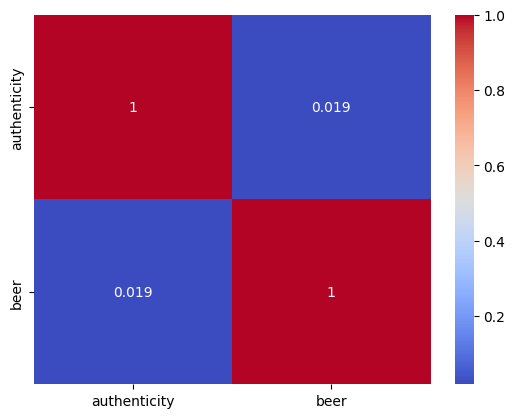

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr_matrix = X.corr().abs()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


In [56]:
from sklearn.model_selection import permutation_test_score
from sklearn.datasets import make_classification

X, y = make_classification(random_state=12345)
estimator = LogisticRegressionCV()
score, permutation_scores, pvalue = permutation_test_score(
    estimator, X, y, random_state=12345
)
print(f"Original Score: {score:.3f}")
print(
    f"Permutation Scores: {permutation_scores.mean():.3f} +/- "
    f"{permutation_scores.std():.3f}"
)
print(f"P-value: {pvalue:.3f}")

Original Score: 0.850
Permutation Scores: 0.499 +/- 0.062
P-value: 0.010


In [ ]:
## GROUPED BY BUSINESS

X = dat_grouped[['authenticity']]
y = dat_grouped['gentrified']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)
auth_model_cv_grp = LogisticRegressionCV(cv = 10, 
                                     random_state=12345, 
                                     #class_weight= 'balanced'
                                     ).fit(X_train, y_train)

# Get the best regularization parameter found
print(auth_model_cv_grp.C_)
pred_auth_grp = auth_model_cv_grp.predict(X_test)
print(confusion_matrix(y_test, pred_auth_grp))
print(auth_model_cv_grp.coef_)      # Array of feature weights
print(auth_model_cv_grp.intercept_) #
print(classification_report(y_test, pred_auth_grp))

[0.0001]
[[891   0]
 [101   0]]
[[-0.02096649]]
[-2.0814161]
              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95       891
         1.0       0.00      0.00      0.00       101

    accuracy                           0.90       992
   macro avg       0.45      0.50      0.47       992
weighted avg       0.81      0.90      0.85       992



/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [58]:
X, y = make_classification(random_state=12345)
estimator = LogisticRegressionCV()
score, permutation_scores, pvalue = permutation_test_score(
    estimator, X, y, random_state=12345
)
print(f"Original Score: {score:.3f}")
print(
    f"Permutation Scores: {permutation_scores.mean():.3f} +/- "
    f"{permutation_scores.std():.3f}"
)
print(f"P-value: {pvalue:.3f}")

Original Score: 0.850
Permutation Scores: 0.499 +/- 0.062
P-value: 0.010


# Using demographic data with authenticity for gentrification pred

In [59]:
dat.predom_poc.value_counts()

predom_poc
0    513551
1    163581
Name: count, dtype: int64

In [82]:
X = dat[['authenticity', 'predom_poc']]
y = dat['gentrified']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)
authrace_model_cv = LogisticRegressionCV(cv = 10, 
                                     random_state=12345, 
                                     #class_weight= 'balanced'
                                     ).fit(X_train, y_train)

# Get the best regularization parameter found
print(authrace_model_cv.C_)
pred_authrace = authrace_model_cv.predict(X_test)
print(confusion_matrix(y_test, pred_authrace))
print(authrace_model_cv.coef_)      # Array of feature weights
print(authrace_model_cv.intercept_) #
print(classification_report(y_test, pred_authrace))

[0.0001]
[[123332      0]
 [ 13026      0]]
[[-0.02053636 -0.20709187]]
[-2.24241006]
              precision    recall  f1-score   support

           0       0.90      1.00      0.95    123332
           1       0.00      0.00      0.00     13026

    accuracy                           0.90    136358
   macro avg       0.45      0.50      0.47    136358
weighted avg       0.82      0.90      0.86    136358



/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

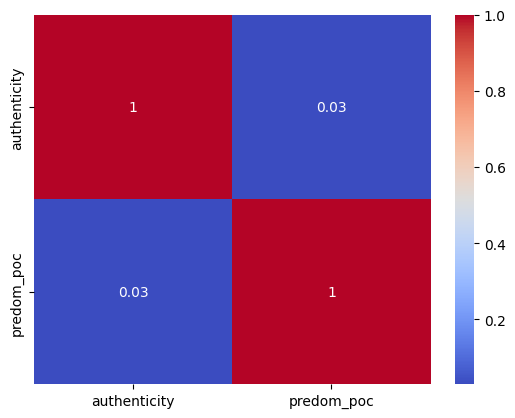

In [61]:
corr_matrix = X.corr().abs()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [62]:
X, y = make_classification(random_state=12345)
estimator = LogisticRegressionCV()
score, permutation_scores, pvalue = permutation_test_score(
    estimator, X, y, random_state=12345
)
print(f"Original Score: {score:.3f}")
print(
    f"Permutation Scores: {permutation_scores.mean():.3f} +/- "
    f"{permutation_scores.std():.3f}"
)
print(f"P-value: {pvalue:.3f}")

Original Score: 0.850
Permutation Scores: 0.499 +/- 0.062
P-value: 0.010


In [63]:
dat_white_subset = dat[dat['predom_poc'] == 0]
dat_poc_subset = dat[dat['predom_poc'] == 1]

X_white = dat_white_subset[['authenticity']]
y_white = dat_white_subset['gentrified']

X_poc = dat_poc_subset[['authenticity']]
y_poc = dat_poc_subset['gentrified']

X_train, X_test, y_train, y_test = train_test_split(X_white, y_white, test_size=0.2, random_state=12345)
authrace_model_w = LogisticRegressionCV(cv = 10, 
                                     random_state=12345, 
                                     #class_weight= 'balanced'
                                     ).fit(X_train, y_train)

# Get the best regularization parameter found
print('predom_white model: \n')
print(authrace_model_w.C_)
pred_authracew = authrace_model_w.predict(X_test)
print(confusion_matrix(y_test, pred_authracew))
print(authrace_model_w.coef_)      # Array of feature weights
print(authrace_model_w.intercept_) #
print(classification_report(y_test, pred_authracew))



predom_white model: 

[0.0001]
[[91502     0]
 [11209     0]]
[[-0.02327852]]
[-2.10419606]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     91502
           1       0.00      0.00      0.00     11209

    accuracy                           0.89    102711
   macro avg       0.45      0.50      0.47    102711
weighted avg       0.79      0.89      0.84    102711



/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X_poc, y_poc, test_size=0.2, random_state=12345)
authrace_model_poc = LogisticRegressionCV(cv = 10, 
                                     random_state=12345, 
                                     #class_weight= 'balanced'
                                     ).fit(X_train, y_train)

print('predom_poc model: \n')
print(authrace_model_poc.C_)
pred_authracepoc = authrace_model_poc.predict(X_test)
print(confusion_matrix(y_test, pred_authracepoc))
print(authrace_model_poc.coef_)      # Array of feature weights
print(authrace_model_poc.intercept_) #
print(classification_report(y_test, pred_authracepoc))

predom_poc model: 

[0.0001]
[[31093     0]
 [ 1624     0]]
[[0.00598485]]
[-2.92002616]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     31093
           1       0.00      0.00      0.00      1624

    accuracy                           0.95     32717
   macro avg       0.48      0.50      0.49     32717
weighted avg       0.90      0.95      0.93     32717



/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [65]:
X_white, y_white = make_classification(random_state=12345)
estimator = LogisticRegressionCV()
score, permutation_scores, pvalue = permutation_test_score(
    estimator, X_white, y_white, random_state=12345
)
print(f"Original Score: {score:.3f}")
print(
    f"Permutation Scores: {permutation_scores.mean():.3f} +/- "
    f"{permutation_scores.std():.3f}"
)
print(f"P-value: {pvalue:.3f}")

Original Score: 0.850
Permutation Scores: 0.499 +/- 0.062
P-value: 0.010


In [66]:
# w GROUPED DATA

dat_white_subset2 = dat_grouped[dat_grouped['predom_poc'] == 0]
dat_poc_subset2 = dat_grouped[dat_grouped['predom_poc'] == 1]

X_white2 = dat_white_subset2[['authenticity']]
y_white2 = dat_white_subset2['gentrified']

X_poc2 = dat_poc_subset2[['authenticity']]
y_poc2 = dat_poc_subset2['gentrified']

X_train, X_test, y_train, y_test = train_test_split(X_white2, y_white2, test_size=0.2, random_state=12345)
authrace_model_w2 = LogisticRegressionCV(cv = 10, 
                                     random_state=12345, 
                                     #class_weight= 'balanced'
                                     ).fit(X_train, y_train)

# Get the best regularization parameter found
print('predom_white model: \n')
print(authrace_model_w2.C_)
pred_authracew2 = authrace_model_w2.predict(X_test)
print(confusion_matrix(y_test, pred_authracew2))
print(authrace_model_w2.coef_)      # Array of feature weights
print(authrace_model_w2.intercept_) #
print(classification_report(y_test, pred_authracew2))

predom_white model: 

[0.0001]
[[557   0]
 [ 88   0]]
[[-0.01507333]]
[-2.01587239]
              precision    recall  f1-score   support

         0.0       0.86      1.00      0.93       557
         1.0       0.00      0.00      0.00        88

    accuracy                           0.86       645
   macro avg       0.43      0.50      0.46       645
weighted avg       0.75      0.86      0.80       645



/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X_poc2, y_poc2, test_size=0.2, random_state=12345)
authrace_model_poc2 = LogisticRegressionCV(cv = 10, 
                                     random_state=12345, 
                                     #class_weight= 'balanced'
                                     ).fit(X_train, y_train)

# Get the best regularization parameter found
print('predom_poc model: \n')
print(authrace_model_poc2.C_)
pred_authracepoc2 = authrace_model_poc2.predict(X_test)
print(confusion_matrix(y_test, pred_authracepoc2))
print(authrace_model_poc2.coef_)      # Array of feature weights
print(authrace_model_poc2.intercept_) #
print(classification_report(y_test, pred_authracepoc2))

predom_poc model: 

[0.0001]
[[289   0]
 [ 29   0]]
[[-0.00674862]]
[-2.32482968]
              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95       289
         1.0       0.00      0.00      0.00        29

    accuracy                           0.91       318
   macro avg       0.45      0.50      0.48       318
weighted avg       0.83      0.91      0.87       318



/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [69]:
#GROUPED, both vars
X = dat_grouped[['authenticity', 'predom_poc']]
y = dat_grouped['gentrified']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)
authrace_model_cv = LogisticRegressionCV(cv = 10, 
                                     random_state=12345, 
                                     #class_weight= 'balanced'
                                     ).fit(X_train, y_train)

# Get the best regularization parameter found
print(authrace_model_cv.C_)
pred_authrace = authrace_model_cv.predict(X_test)
print(confusion_matrix(y_test, pred_authrace))
print(authrace_model_cv.coef_)      # Array of feature weights
print(authrace_model_cv.intercept_) #
print(classification_report(y_test, pred_authrace))

[0.0001]
[[891   0]
 [101   0]]
[[-0.02096804 -0.00262997]]
[-2.08051568]
              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95       891
         1.0       0.00      0.00      0.00       101

    accuracy                           0.90       992
   macro avg       0.45      0.50      0.47       992
weighted avg       0.81      0.90      0.85       992



/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]